In [ ]:
# Cell 0: Install dependencies

!pip install transformers torch sentencepiece datasets -q

In [ ]:
# Cell 1: Imports

import torch
from transformers import AutoTokenizer, pipeline
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple, Dict
import re
from tqdm import tqdm
from functools import lru_cache
import warnings
import unicodedata
warnings.filterwarnings('ignore')

print("✓ Libraries imported")

✓ Libraries imported


In [ ]:
# Cell 2: HuggingFace Login (Kaggle version — from Secrets) + Load Dataset
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)
print("✓ HuggingFace logged in via Kaggle Secret")

from datasets import load_dataset
dataset = load_dataset("Shelton1013/SwitchLingua_text")
print(f"Dataset size: {len(dataset['train'])}")


✓ HuggingFace logged in via Kaggle Secret


README.md: 0.00B [00:00, ?B/s]

Arabic_eng.csv:   0%|          | 0.00/55.7M [00:00<?, ?B/s]

Can_Eng.csv:   0%|          | 0.00/694M [00:00<?, ?B/s]

Chinese_eng.csv:   0%|          | 0.00/56.7M [00:00<?, ?B/s]

...

Russian_eng.csv:   0%|          | 0.00/55.4M [00:00<?, ?B/s]

Spanish_eng.csv:   0%|          | 0.00/50.8M [00:00<?, ?B/s]

Vietnamese_eng.csv:   0%|          | 0.00/57.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/234172 [00:00<?, ? examples/s]

Dataset size: 234172


In [ ]:
# Cell 3: Configuration — 15 pairs, 8 train / 7 zero-shot
# CHANGE: tokenizer → bert-base-multilingual-cased

ALL_LANGUAGE_PAIRS = [
    ("Cantonese", "English"),
    ("Arabic", "English"),
    ("Philippines", "English"),
    ("German", "French"),
    ("Chinese", "English"),
    ("Vietnamese", "English"),
    ("Malay", "English"),
    ("Japanese", "English"),
    ("Hindi", "English"),
    ("Korean", "English"),
    ("Spanish", "English"),
    ("French", "English"),
    ("Russian", "English"),
    ("Italian", "English"),
    ("German", "English"),
]

TRAIN_PAIRS = [
    ("Chinese", "English"),
    ("Hindi", "English"),
    ("Italian", "English"),
    ("German", "English"),
    ("Arabic", "English"),
    ("Japanese", "English"),
    ("Vietnamese", "English"),
    ("Spanish", "English"),
]

ZEROSHOT_PAIRS = [
    ("Korean", "English"),
    ("Russian", "English"),
    ("French", "English"),
    ("Malay", "English"),
    ("Philippines", "English"),
    ("German", "French"),
    ("Cantonese", "English"),
]

CONFIG = {
    'model_name': 'bert-base-multilingual-cased',    # ★ mBERT
    'lid_model': 'papluca/xlm-roberta-base-language-detection',  # unchanged
    'max_samples_per_pair': 6000,
    'device': 0 if torch.cuda.is_available() else -1,
}

print(f"Device: {'GPU' if CONFIG['device'] == 0 else 'CPU'}")
print(f"Backbone: {CONFIG['model_name']}")
print(f"All language pairs: {len(ALL_LANGUAGE_PAIRS)}")
print(f"Train pairs: {len(TRAIN_PAIRS)}")
print(f"Zero-shot pairs: {len(ZEROSHOT_PAIRS)}")

# ★ mBERT tokenizer (WordPiece, not SentencePiece)
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f"✓ Tokenizer loaded: {CONFIG['model_name']}  |  vocab size: {tokenizer.vocab_size:,}")

test_tokens = tokenizer.tokenize("I went to das Haus today")
print(f"  Tokenization test: {test_tokens}")

Device: GPU
Backbone: bert-base-multilingual-cased
All language pairs: 15
Train pairs: 8
Zero-shot pairs: 7


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✓ Tokenizer loaded: bert-base-multilingual-cased  |  vocab size: 119,547
  Tokenization test: ['I', 'went', 'to', 'das', 'Haus', 'today']


In [ ]:
# Cell 4: Production-Grade LID System (unchanged — same papluca model)
def is_language_neutral_content(text: str) -> bool:
    if not text or not text.strip():
        return True
    return not any(unicodedata.category(c).startswith('L') for c in text.strip())


class ProductionLID:
    def __init__(self, model_name: str = "papluca/xlm-roberta-base-language-detection"):
        print("Loading Transformer-based LID model...")
        self.device = 0 if torch.cuda.is_available() else -1
        self.lid_model = pipeline(
            "text-classification",
            model=model_name,
            device=self.device,
            batch_size=32,
        )

        self.lang_map = {
            'en': 'English',  'zh': 'Chinese', 'ja': 'Japanese',
            'ar': 'Arabic',   'hi': 'Hindi',   'vi': 'Vietnamese',
            'ru': 'Russian',  'fr': 'French',  'de': 'German',
            'es': 'Spanish',  'it': 'Italian', 'ko': 'Korean',
            'ms': 'Malay',    'tl': 'Filipino',
        }

        self.unicode_ranges = {
            'Japanese': [(0x3040, 0x309F), (0x30A0, 0x30FF)],
            'Korean':   [(0xAC00, 0xD7AF)],
            'Arabic':   [(0x0600, 0x06FF)],
            'Hindi':    [(0x0900, 0x097F)],
            'Russian':  [(0x0400, 0x04FF)],
            'Chinese':  [(0x4E00, 0x9FFF), (0x3400, 0x4DBF)],
        }

        self.lexicons = {
            'Vietnamese': frozenset([
                'có', 'là', 'không', 'và', 'của', 'cho', 'trong', 'với', 'được', 'này',
                'các', 'một', 'những', 'khi', 'nhưng', 'hay', 'để', 'từ', 'đã', 'cũng',
                'phải', 'sẽ', 'nếu', 'vì', 'hoặc', 'đến', 'ra', 'về', 'năm', 'người',
            ]),
            'Cantonese': frozenset([
                '嘅', '咗', '唔', '係', '喺', '咁', '哋', '嚟', '噉', '嘢', '啲', '咩',
                '冇', '佢', '乜', '嗰', '吖', '嘞', '噃', '啩', '咯', '㗎',
            ]),
            'German': frozenset([
                'ich', 'nicht', 'ist', 'das', 'die', 'der', 'und', 'ein', 'zu', 'mit',
                'sich', 'auf', 'auch', 'dass', 'aber', 'noch', 'wird', 'beim', 'vom',
                'haben', 'sein', 'war', 'sind', 'wurde', 'wenn', 'durch', 'nach', 'oder',
            ]),
            'French': frozenset([
                'je', 'ne', 'pas', 'est', 'les', 'des', 'une', 'que', 'qui', 'dans',
                'avec', 'sur', 'pour', 'par', 'mais', 'ont', 'être', 'très', 'bien',
                'nous', 'vous', 'ils', 'elle', 'tout', 'plus', 'cette', 'comme', 'aux',
            ]),
            'Malay': frozenset([
                'dan', 'yang', 'ini', 'itu', 'di', 'dengan', 'untuk', 'tidak', 'ada',
                'dari', 'dalam', 'akan', 'pada', 'juga', 'saya', 'sudah', 'bisa',
                'mereka', 'seperti', 'tetapi', 'atau', 'hanya', 'oleh', 'karena',
            ]),
            'Filipino': frozenset([
                'ang', 'mga', 'sa', 'na', 'ng', 'ko', 'ka', 'niya', 'siya', 'ito',
                'ako', 'mo', 'namin', 'nila', 'pero', 'kasi', 'talaga', 'lang',
                'din', 'dito', 'yung', 'parang', 'dapat', 'pwede', 'gusto',
            ]),
            'Korean': frozenset([
                '이', '그', '저', '것', '수', '등', '들', '및', '을', '를',
                '에', '의', '가', '으로', '하다', '있다', '되다', '없다',
            ]),
            'Spanish': frozenset([
                'el', 'la', 'los', 'las', 'un', 'una', 'que', 'en', 'es', 'por',
                'con', 'para', 'como', 'pero', 'más', 'este', 'ya', 'todo', 'esta',
                'ser', 'también', 'fue', 'había', 'muy', 'puede', 'todos', 'así',
                'nos', 'cuando', 'algo', 'entre', 'sin', 'sobre', 'tiene', 'donde',
            ]),
        }

        self.ngram_features = {
            'Vietnamese': frozenset('àáâãèéêìíòóôõùúýăđơưạảấầẩẫậắằẳẵặẹẻẽếềểễệỉịọỏốồổỗộớờởỡợụủứừửữựỳỵỷỹ'),
            'German':     frozenset('äöüßÄÖÜ'),
            'French':     frozenset('çœæÇŒÆ'),
            'Spanish':    frozenset('ñ¿¡Ñ'),
        }

        self._word_cache: dict[str, str] = {}
        print(f"✓ LID model loaded on {'GPU' if self.device >= 0 else 'CPU'}")

    def _unicode_check(self, text: str) -> str | None:
        for ch in text:
            cp = ord(ch)
            for lang, ranges in self.unicode_ranges.items():
                for lo, hi in ranges:
                    if lo <= cp <= hi:
                        return lang
        return None

    def _ngram_check(self, text: str, lang1: str, lang2: str) -> str | None:
        for lang, char_set in self.ngram_features.items():
            if lang not in (lang1, lang2):
                continue
            if any(c in char_set for c in text):
                return lang
        return None

    def _transformer_detect_single(self, text: str, lang1: str, lang2: str) -> str:
        try:
            results = self.lid_model(text, top_k=3)
            for r in results:
                label = r['label']
                detected = self.lang_map.get(label)
                if label == 'zh':
                    detected = 'Cantonese' if 'Cantonese' in (lang1, lang2) else 'Chinese'
                if detected in (lang1, lang2):
                    return detected
        except Exception:
            pass
        return lang1

    def _batch_transformer_detect(self, texts: list[str],
                                   lang1: str, lang2: str) -> list[str]:
        if not texts:
            return []
        unique = list(dict.fromkeys(texts))
        result_map: dict[str, str] = {}
        try:
            batch_results = self.lid_model(unique, top_k=3, batch_size=32)
            for word, top3 in zip(unique, batch_results):
                resolved = lang1
                for r in top3:
                    label = r['label']
                    detected = self.lang_map.get(label)
                    if label == 'zh':
                        detected = 'Cantonese' if 'Cantonese' in (lang1, lang2) else 'Chinese'
                    if detected in (lang1, lang2):
                        resolved = detected
                        break
                result_map[word] = resolved
        except Exception:
            result_map = {w: lang1 for w in unique}
        return [result_map[t] for t in texts]

    def detect_language(self, text: str, lang1: str, lang2: str) -> str:
        clean = re.sub(r'[^\w\s]', '', text).strip()
        if not clean or is_language_neutral_content(clean):
            return 'neutral'
        hit = self._unicode_check(clean)
        if hit and hit in (lang1, lang2):
            return hit
        word_lower = clean.lower().split()[0]
        for lang, lexicon in self.lexicons.items():
            if lang not in (lang1, lang2):
                continue
            if word_lower in lexicon or any(c in lexicon for c in clean):
                return lang
        hit = self._ngram_check(clean, lang1, lang2)
        if hit:
            return hit
        cached = self._word_cache.get(clean)
        if cached is not None:
            return cached
        result = self._transformer_detect_single(clean, lang1, lang2)
        self._cache_set(clean, result)
        return result

    def word_level_lid(self, text: str, lang1: str, lang2: str
                       ) -> Tuple[List[str], List[str]]:
        words = text.split()
        lids: list[str | None] = []
        l4_positions: list[int] = []
        l4_texts: list[str] = []

        for i, word in enumerate(words):
            clean = re.sub(r'[^\w]', '', word)
            if not clean or is_language_neutral_content(clean):
                lids.append('neutral')
                continue
            hit = self._unicode_check(clean)
            if hit and hit in (lang1, lang2):
                lids.append(hit)
                continue
            hit_lang = None
            word_lower = clean.lower()
            for lang, lexicon in self.lexicons.items():
                if lang not in (lang1, lang2):
                    continue
                if word_lower in lexicon or any(c in lexicon for c in clean):
                    hit_lang = lang
                    break
            if hit_lang:
                lids.append(hit_lang)
                continue
            hit = self._ngram_check(clean, lang1, lang2)
            if hit:
                lids.append(hit)
                continue
            cached = self._word_cache.get(clean)
            if cached is not None:
                lids.append(cached)
                continue
            lids.append(None)
            l4_positions.append(i)
            l4_texts.append(clean)

        if l4_texts:
            detected = self._batch_transformer_detect(l4_texts, lang1, lang2)
            for pos, lang, clean in zip(l4_positions, detected, l4_texts):
                lids[pos] = lang
                self._cache_set(clean, lang)

        lids = [l if l is not None else lang1 for l in lids]
        return words, lids

    def _cache_set(self, text: str, lang: str) -> None:
        if len(self._word_cache) >= 100_000:
            self._word_cache.clear()
        self._word_cache[text] = lang


print("Initializing Production LID System...")
production_lid = ProductionLID()
print("✓ LID System Ready\n")

In [ ]:
# Cell 5: Subword alignment + Label generation
# CHANGE: neutral check uses '##' instead of '▁'
def align_subwords_to_words(words: List[str],
                             word_lids: List[str]) -> Tuple[List[str], List[str]]:
    assert len(words) == len(word_lids), (
        f"Length mismatch: {len(words)} words vs {len(word_lids)} lids"
    )
    tokens, token_lids = [], []
    for word, lid in zip(words, word_lids):
        word_tokens = tokenizer.tokenize(word)
        if not word_tokens:
            continue
        for token in word_tokens:
            # ★ Strip '##' for mBERT (was '▁' for XLM-R)
            clean_token = token.replace('##', '').strip()
            if not clean_token or is_language_neutral_content(clean_token):
                tokens.append(token)
                token_lids.append('neutral')
            else:
                tokens.append(token)
                token_lids.append(lid)
    return tokens, token_lids


def generate_labels(token_lids: List[str]) -> Tuple[List[int], List[int]]:
    n = len(token_lids)
    if n < 2:
        return [], []

    next_nn: List[int | None] = [None] * n
    last_nn = None
    for i in range(n - 1, -1, -1):
        if token_lids[i] != 'neutral':
            last_nn = i
        next_nn[i] = last_nn

    y_switch   = []
    y_duration = []

    for t in range(n - 1):
        current_lid = token_lids[t]
        if current_lid == 'neutral':
            y_switch.append(0)
            y_duration.append(-1)
            continue

        next_pos = next_nn[t + 1] if t + 1 < n else None
        if next_pos is None:
            y_switch.append(0)
            y_duration.append(-1)
            continue

        next_lid  = token_lids[next_pos]
        is_switch = current_lid != next_lid
        y_switch.append(1 if is_switch else 0)

        if is_switch:
            burst_len = 1
            for i in range(next_pos + 1, n):
                if token_lids[i] == 'neutral':
                    continue
                if token_lids[i] == next_lid:
                    burst_len += 1
                else:
                    break
            if burst_len <= 2:
                y_duration.append(0)
            elif burst_len <= 6:
                y_duration.append(1)
            else:
                y_duration.append(2)
        else:
            y_duration.append(-1)

    return y_switch, y_duration

In [ ]:
# Cell 6: Sample processing + Language-pair analysis
def process_sample(sample: dict, lang1: str, lang2: str) -> dict | None:
    raw = sample.get('data_generation_result', '')
    if isinstance(raw, list):
        text = ' '.join(str(s) for s in raw if s)
    else:
        text = raw if isinstance(raw, str) else ''
    if not text or not text.strip():
        return None
    try:
        words, word_lids = production_lid.word_level_lid(text, lang1, lang2)
        tokens, token_lids = align_subwords_to_words(words, word_lids)
        if len(tokens) < 2:
            return None
        y_switch, y_duration = generate_labels(token_lids)
        return {
            'text':       text,
            'tokens':     tokens,
            'token_lids': token_lids,
            'y_switch':   y_switch,
            'y_duration': y_duration,
            'cs_type':    sample.get('cs_type',     'unknown'),
            'cs_function':sample.get('cs_function', 'unknown'),
        }
    except Exception as e:
        print(f"[process_sample] {lang1}-{lang2} | error: {type(e).__name__}: {e}")
        return None


def analyze_language_pair(dataset_split, lang1: str, lang2: str,
                           max_samples: int = 6000) -> dict | None:
    print(f"\n{'='*70}")
    print(f"Processing: {lang1} - {lang2}")
    print(f"{'='*70}")

    filtered_data = dataset_split.filter(
        lambda x: (x.get('first_language') == lang1 and x.get('second_language') == lang2) or
                  (x.get('first_language') == lang2 and x.get('second_language') == lang1)
    )

    print(f"Found {len(filtered_data)} samples")
    if len(filtered_data) == 0:
        print("No samples found, skipping...")
        return None

    sample_size   = min(len(filtered_data), max_samples)
    filtered_data = filtered_data.select(range(sample_size))

    stats = {
        'lang_pair':              f"{lang1}-{lang2}",
        'total_samples':          0,
        'total_tokens':           0,
        'total_switches':         0,
        'duration_distribution':  Counter(),
        'cs_type_distribution':   Counter(),
        'switch_rate_per_sample': [],
        'processed_samples':      [],
    }

    print(f"Processing {sample_size} samples...")
    for idx in tqdm(range(sample_size), desc=f"  {lang1}-{lang2}"):
        result = process_sample(filtered_data[idx], lang1, lang2)
        if result is None:
            continue

        stats['total_samples']  += 1
        stats['total_tokens']   += len(result['tokens'])
        stats['total_switches'] += sum(result['y_switch'])

        for dur in result['y_duration']:
            if dur != -1:
                stats['duration_distribution'][dur] += 1

        stats['cs_type_distribution'][result['cs_type']] += 1

        if result['tokens']:
            stats['switch_rate_per_sample'].append(
                sum(result['y_switch']) / len(result['tokens'])
            )

        stats['processed_samples'].append(result)

    failed = sample_size - stats['total_samples']
    print(f"✓ Processed: {stats['total_samples']:,}  |  Failed: {failed}")

    if stats['total_tokens'] > 0:
        sr = stats['total_switches'] / stats['total_tokens']
        print(f"  Tokens: {stats['total_tokens']:,}  |  Switches: {stats['total_switches']:,}  |  Rate: {sr:.2%}")

    dur_total = sum(stats['duration_distribution'].values())
    if dur_total:
        labels = ['Small (1-2)', 'Medium (3-6)', 'Large (7+)']
        parts = []
        for k in sorted(stats['duration_distribution']):
            c = stats['duration_distribution'][k]
            parts.append(f"{labels[k]}={c}")
        print(f"  Duration dist: {', '.join(parts)}")

    return stats

In [ ]:
# Cell 7: Batch processing ALL 15 language pairs (mBERT tokenizer)
print("\n" + "="*70)
print("BATCH PROCESSING ALL 15 LANGUAGE PAIRS (mBERT tokenizer)")
print("="*70)

all_stats = {}

for lang1, lang2 in ALL_LANGUAGE_PAIRS:
    try:
        stats = analyze_language_pair(
            dataset['train'], lang1, lang2,
            max_samples=CONFIG['max_samples_per_pair']
        )
        if stats is not None:
            pair_key = f"{lang1}-{lang2}"
            all_stats[pair_key] = stats
    except Exception as e:
        print(f"  Error processing {lang1}-{lang2}: {e}")
        continue

print(f"\n{'='*70}")
print(f"✓ COMPLETED! Processed {len(all_stats)} / {len(ALL_LANGUAGE_PAIRS)} language pairs")
print(f"Total samples: {sum(s['total_samples'] for s in all_stats.values()):,}")
print(f"Total tokens:  {sum(s['total_tokens'] for s in all_stats.values()):,}")
print(f"{'='*70}\n")

In [ ]:
# Cell 8: Save pickle to /kaggle/working/ (persists as Notebook Output)
import pickle
import os

PICKLE_PATH = '/kaggle/working/all_15pairs_stats_mbert.pkl'

with open(PICKLE_PATH, 'wb') as f:
    pickle.dump(all_stats, f)

size_mb = os.path.getsize(PICKLE_PATH) / 1024**2
print(f"✓ Saved to: {PICKLE_PATH}  ({size_mb:.1f} MB, {len(all_stats)} pairs)")
print()
print(f"{'Language Pair':<25} {'Samples':<10}")
print('-' * 35)
for k in all_stats:
    print(f"  {k:<23} {len(all_stats[k]['processed_samples']):<10}")


In [ ]:
# Cell 9: Model - mBERT Causal Full Fine-Tuning
import gc
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import f1_score, classification_report
from transformers import BertModel, BertTokenizer

# --- Config (same as XLM-R Causal) ---
MAX_LEN      = 256
BATCH_SIZE   = 32
NUM_EPOCHS   = 16
BASE_LR      = 1e-5
HEAD_LR      = BASE_LR * 50  # 5e-4
WARMUP_RATIO = 0.1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print(f"✓ Device: {device}")

print("Loading mBERT tokenizer...")
mbert_tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")
print(f"✓ Tokenizer loaded  |  vocab size: {len(mbert_tokenizer)}")


# --- Dataset (uses [CLS]/[SEP]) ---

class MBERTCodeSwitchDataset(Dataset):
    def __init__(self, samples: list[dict], tokenizer, max_len: int = MAX_LEN):
        self.items = []
        for s in samples:
            ids = tokenizer.convert_tokens_to_ids(s['tokens'])
            ids = [tokenizer.cls_token_id] + ids + [tokenizer.sep_token_id]

            sw_raw  = [x if x != -1 else -100 for x in s['y_switch']]
            dur_raw = [x if x != -1 else -100 for x in s['y_duration']]
            sw  = [-100] + sw_raw  + [-100]
            dur = [-100] + dur_raw + [-100]

            ids = ids[:max_len]
            n   = len(ids)
            if n < 2:
                continue

            label_len = n - 1
            sw  = sw[:label_len]
            dur = dur[:label_len]
            if len(sw) != label_len or len(dur) != label_len:
                continue

            self.items.append({
                'input_ids':  torch.tensor(ids, dtype=torch.long),
                'y_switch':   torch.tensor(sw,  dtype=torch.long),
                'y_duration': torch.tensor(dur, dtype=torch.long),
            })
        print(f"✓ Dataset ready - {len(self.items)} samples")

    def __len__(self):          return len(self.items)
    def __getitem__(self, i):   return self.items[i]


def mbert_collate(batch):
    pad_id = mbert_tokenizer.pad_token_id
    ids  = pad_sequence([b['input_ids']  for b in batch], batch_first=True, padding_value=pad_id)
    sw   = pad_sequence([b['y_switch']   for b in batch], batch_first=True, padding_value=-100)
    dur  = pad_sequence([b['y_duration'] for b in batch], batch_first=True, padding_value=-100)
    mask = (ids != pad_id).long()
    return {'input_ids': ids, 'attention_mask': mask, 'y_switch': sw, 'y_duration': dur}


def build_datasets(all_stats, pairs, tokenizer, train_ratio=0.8):
    train_sets, val_sets = [], []
    print("Building mBERT datasets...")
    for lang1, lang2 in pairs:
        key = f"{lang1}-{lang2}"
        if key not in all_stats or not all_stats[key]['processed_samples']:
            print(f"  Warning: {key} not found, skipping.")
            continue
        samples  = all_stats[key]['processed_samples']
        split_at = int(len(samples) * train_ratio)
        tr = MBERTCodeSwitchDataset(samples[:split_at], tokenizer)
        va = MBERTCodeSwitchDataset(samples[split_at:],  tokenizer)
        print(f"  {key:<25} total={len(samples)}  train={len(tr)}  val={len(va)}")
        train_sets.append(tr); val_sets.append(va)
    return ConcatDataset(train_sets), ConcatDataset(val_sets)


# --- Causal Mask (identical to XLM-R version) ---

def make_causal_mask(seq_len, device):
    causal = torch.triu(
        torch.ones(seq_len, seq_len, device=device), diagonal=1
    )
    causal = causal * (-1e9)
    return causal.unsqueeze(0).unsqueeze(0)


def combine_pad_and_causal_mask(attention_mask, device):
    B, L = attention_mask.shape
    pad_mask = (1.0 - attention_mask.float()).unsqueeze(1).unsqueeze(2) * (-1e9)
    causal = make_causal_mask(L, device)
    return pad_mask + causal


# --- Model (BertModel with Causal Mask) ---

class CausalMBERTCodeSwitchPredictor(nn.Module):
    """mBERT with CAUSAL attention mask. Position t can ONLY attend to 0..t."""
    def __init__(self, model_name="bert-base-multilingual-cased",
                 dropout=0.1, freeze_encoder=False):
        super().__init__()
        print(f"Loading {model_name} (CAUSAL mode)...")
        self.encoder = BertModel.from_pretrained(model_name)
        d_model = self.encoder.config.hidden_size

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False
            print("  Encoder FROZEN")
        else:
            print("  Encoder UNFROZEN - full fine-tuning with causal mask")

        def _head(out_dim):
            return nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(d_model, d_model // 2),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model // 2, out_dim),
            )

        self.switch_head   = _head(2)
        self.duration_head = _head(3)

        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"✓ Model ready  |  total={total:,}  trainable={trainable:,}")

    def forward(self, input_ids, attention_mask=None):
        if attention_mask is not None:
            extended_mask = combine_pad_and_causal_mask(
                attention_mask, input_ids.device
            )
        else:
            B, L = input_ids.shape
            extended_mask = make_causal_mask(L, input_ids.device).expand(B, -1, -1, -1)

        out = self.encoder(
            input_ids=input_ids,
            attention_mask=extended_mask,
            return_dict=True,
        )
        hidden = out.last_hidden_state[:, :-1, :]
        return self.switch_head(hidden), self.duration_head(hidden)


# --- Compute class weights (unchanged) ---

def compute_class_weights(loader, num_sw_classes=2, num_dur_classes=3):
    sw_counts  = torch.zeros(num_sw_classes)
    dur_counts = torch.zeros(num_dur_classes)
    for batch in loader:
        y_sw  = batch['y_switch'].reshape(-1)
        y_dur = batch['y_duration'].reshape(-1)
        for c in range(num_sw_classes):
            sw_counts[c] += (y_sw == c).sum()
        for c in range(num_dur_classes):
            dur_counts[c] += (y_dur == c).sum()
    sw_w  = (1.0 / sw_counts);  sw_w  /= sw_w.min()
    dur_w = (1.0 / dur_counts); dur_w /= dur_w.min()
    print(f"  Switch  counts : {sw_counts.long().tolist()}")
    print(f"  Switch  weights: {[f'{w:.4f}' for w in sw_w.tolist()]}")
    print(f"  Duration counts: {dur_counts.long().tolist()}")
    print(f"  Duration weights: {[f'{w:.4f}' for w in dur_w.tolist()]}")
    return sw_w, dur_w


# --- Warmup + Cosine Scheduler ---

class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_steps, total_steps, last_epoch=-1):
        self.warmup_steps = warmup_steps
        self.total_steps  = total_steps
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        step = max(1, self.last_epoch)
        if step < self.warmup_steps:
            scale = step / max(1, self.warmup_steps)
        else:
            import math
            progress = (step - self.warmup_steps) / max(1, self.total_steps - self.warmup_steps)
            scale = 0.5 * (1 + math.cos(math.pi * progress))
        return [base_lr * scale for base_lr in self.base_lrs]


# --- Training ---

def train_epoch(model, loader, optimiser, scheduler, device,
                sw_criterion, dur_criterion):
    model.train()
    sw_losses, dur_losses = [], []
    for batch in tqdm(loader, desc="  train", leave=False):
        ids   = batch['input_ids'].to(device)
        mask  = batch['attention_mask'].to(device)
        y_sw  = batch['y_switch'].to(device)
        y_dur = batch['y_duration'].to(device)

        sw_logits, dur_logits = model(ids, mask)

        loss_sw = sw_criterion(sw_logits.reshape(-1, 2), y_sw.reshape(-1))

        dur_flat  = y_dur.reshape(-1)
        dlog_flat = dur_logits.reshape(-1, 3)
        valid     = dur_flat >= 0
        loss_dur  = (
            dur_criterion(dlog_flat[valid], dur_flat[valid])
            if valid.any()
            else torch.tensor(0.0, device=device)
        )

        loss = loss_sw + 1.0 * loss_dur

        optimiser.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        scheduler.step()

        sw_losses.append(loss_sw.item())
        dur_losses.append(loss_dur.item())

    return {'loss_sw': np.mean(sw_losses), 'loss_dur': np.mean(dur_losses)}


# --- Evaluation ---

def evaluate(model, loader, device, sw_criterion=None, dur_criterion=None):
    model.eval()
    sw_pred, sw_true   = [], []
    dur_pred, dur_true = [], []
    val_sw_losses, val_dur_losses = [], []

    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)
            y_sw  = batch['y_switch'].to(device)
            y_dur = batch['y_duration'].to(device)

            sw_logits, dur_logits = model(ids, mask)
            sw_hat  = sw_logits.argmax(-1).cpu()
            dur_hat = dur_logits.argmax(-1).cpu()

            if sw_criterion is not None:
                loss_sw = sw_criterion(sw_logits.reshape(-1, 2), y_sw.reshape(-1))
                val_sw_losses.append(loss_sw.item())
            if dur_criterion is not None:
                dur_flat  = y_dur.reshape(-1)
                dlog_flat = dur_logits.reshape(-1, 3)
                valid = dur_flat >= 0
                if valid.any():
                    loss_dur = dur_criterion(dlog_flat[valid], dur_flat[valid])
                    val_dur_losses.append(loss_dur.item())

            y_sw_cpu  = batch['y_switch']
            y_dur_cpu = batch['y_duration']
            B, L1 = sw_hat.shape
            for b in range(B):
                for t in range(L1):
                    if y_sw_cpu[b, t].item() != -100:
                        sw_pred.append(sw_hat[b, t].item())
                        sw_true.append(y_sw_cpu[b, t].item())
                    if y_dur_cpu[b, t].item() not in (-1, -100):
                        dur_pred.append(dur_hat[b, t].item())
                        dur_true.append(y_dur_cpu[b, t].item())

    sw_f1  = f1_score(sw_true,  sw_pred,  average='macro', zero_division=0)
    dur_f1 = f1_score(dur_true, dur_pred, average='macro', zero_division=0) if dur_true else 0.0

    result = {
        'switch_f1':       sw_f1,
        'duration_f1':     dur_f1,
        'switch_report':   classification_report(
                               sw_true, sw_pred,
                               target_names=['no-switch', 'switch'], zero_division=0),
        'duration_report': classification_report(
                               dur_true, dur_pred,
                               target_names=['small', 'medium', 'large'], zero_division=0)
                           if dur_true else "No duration predictions.",
    }
    if val_sw_losses:
        result['val_loss_sw']  = np.mean(val_sw_losses)
    if val_dur_losses:
        result['val_loss_dur'] = np.mean(val_dur_losses)
    return result


def evaluate_per_pair(model, all_stats, pairs, tokenizer, device):
    results = {}
    for lang1, lang2 in pairs:
        key = f"{lang1}-{lang2}"
        if key not in all_stats or not all_stats[key]['processed_samples']:
            continue
        samples  = all_stats[key]['processed_samples']
        split_at = int(len(samples) * 0.8)
        val_ds   = MBERTCodeSwitchDataset(samples[split_at:], tokenizer)
        if len(val_ds) == 0:
            continue
        ldr = DataLoader(val_ds, batch_size=BATCH_SIZE,
                         shuffle=False, collate_fn=mbert_collate)
        results[key] = evaluate(model, ldr, device)
    return results

In [ ]:
# Cell 10: Main pipeline — mBERT Causal Train on 8 pairs
# Kaggle additions:
#   - DataParallel across 2 T4s
#   - Per-epoch checkpoint to /kaggle/working/ckpt_latest_mbert.pt
#   - Resume from checkpoint if exists (set RESUME=True)
#   - Time budget guard (stops cleanly before 12h hard limit)

import os
import time

CKPT_LATEST  = "/kaggle/working/ckpt_latest_mbert.pt"
BEST_MODEL   = "/kaggle/working/best_mbert_causal_final.pt"
MAX_TRAIN_HOURS = 8.0   # Kaggle 12h limit — leave 4h buffer
RESUME = True


def run_pipeline(all_stats, tokenizer, epochs=NUM_EPOCHS):
    gc.collect(); torch.cuda.empty_cache()

    train_ds, val_ds = build_datasets(all_stats, TRAIN_PAIRS, tokenizer)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True,  collate_fn=mbert_collate, num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=mbert_collate, num_workers=2)

    print("Computing class weights from training data...")
    sw_w, dur_w = compute_class_weights(train_loader)
    sw_w  = sw_w.to(device)
    dur_w = dur_w.to(device)

    sw_criterion  = nn.CrossEntropyLoss(weight=sw_w,  ignore_index=-100)
    dur_criterion = nn.CrossEntropyLoss(weight=dur_w)

    print(f"  Switch CE  weights: {sw_w.cpu().tolist()}")
    print(f"  Duration CE weights: {dur_w.cpu().tolist()}")

    # --- Build model + wrap in DataParallel if multi-GPU ---
    model = CausalMBERTCodeSwitchPredictor(freeze_encoder=False).to(device)
    use_dp = torch.cuda.device_count() >= 2
    if use_dp:
        model = nn.DataParallel(model)
        print(f"✓ DataParallel enabled across {torch.cuda.device_count()} GPUs")
    else:
        print("  Running on single GPU (DataParallel not used)")

    def unwrap(m):
        return m.module if isinstance(m, nn.DataParallel) else m

    optimiser = torch.optim.AdamW([
        {'params': unwrap(model).encoder.parameters(),       'lr': BASE_LR},
        {'params': unwrap(model).switch_head.parameters(),   'lr': HEAD_LR},
        {'params': unwrap(model).duration_head.parameters(), 'lr': HEAD_LR},
    ], weight_decay=0.01)

    total_steps  = len(train_loader) * epochs
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler    = WarmupCosineScheduler(optimiser, warmup_steps, total_steps)

    # --- Resume from checkpoint if exists ---
    start_epoch = 1
    history     = []
    best_sw_f1  = 0.0

    if RESUME and os.path.exists(CKPT_LATEST):
        print(f"\n→ Found checkpoint: {CKPT_LATEST}")
        ckpt = torch.load(CKPT_LATEST, map_location=device)
        unwrap(model).load_state_dict(ckpt['model_state'])
        optimiser.load_state_dict(ckpt['optim_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        best_sw_f1  = ckpt['best_sw_f1']
        history     = ckpt['history']
        start_epoch = ckpt['epoch'] + 1
        print(f"✓ Resumed from epoch {ckpt['epoch']}, continuing from epoch {start_epoch}")
        print(f"  Best switch F1 so far: {best_sw_f1:.4f}")
    else:
        print("\n→ Fresh training (no checkpoint found or RESUME=False)")

    print(f"\n  Mode: CAUSAL FULL FINE-TUNING (mBERT)")
    print(f"  Attention: position t can ONLY see 0..t (no future)")
    print(f"  Encoder LR: {BASE_LR}  |  Head LR: {HEAD_LR}")
    print(f"  Total steps: {total_steps}  |  Warmup steps: {warmup_steps}")
    print(f"  Train pairs: {len(TRAIN_PAIRS)}  |  Zero-shot pairs: {len(ZEROSHOT_PAIRS)}")
    print(f"  Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")
    print(f"  Training on: {device}  |  Time budget: {MAX_TRAIN_HOURS}h\n")

    start_time = time.time()

    for epoch in range(start_epoch, epochs + 1):
        losses  = train_epoch(model, train_loader, optimiser, scheduler,
                              device, sw_criterion, dur_criterion)
        metrics = evaluate(model, val_loader, device,
                           sw_criterion, dur_criterion)
        pair_f1s = {k: v['switch_f1'] for k, v in
                    evaluate_per_pair(model, all_stats, TRAIN_PAIRS,
                                      tokenizer, device).items()}

        current_lrs = scheduler.get_last_lr()
        elapsed_h = (time.time() - start_time) / 3600

        history.append({
            'epoch':        epoch,
            'loss_sw':      losses['loss_sw'],
            'loss_dur':     losses['loss_dur'],
            'val_loss_sw':  metrics.get('val_loss_sw', 0.0),
            'val_loss_dur': metrics.get('val_loss_dur', 0.0),
            'switch_f1':    metrics['switch_f1'],
            'duration_f1':  metrics['duration_f1'],
            'pair_f1s':     pair_f1s,
            'encoder_lr':   current_lrs[0],
            'elapsed_h':    elapsed_h,
        })

        print(f"Epoch {epoch:02d} | "
              f"train_sw={losses['loss_sw']:.4f}  train_dur={losses['loss_dur']:.4f} | "
              f"val_sw={metrics.get('val_loss_sw', 0):.4f}  "
              f"val_dur={metrics.get('val_loss_dur', 0):.4f} | "
              f"switch_F1={metrics['switch_f1']:.4f}  "
              f"duration_F1={metrics['duration_f1']:.4f}  | "
              f"enc_lr={current_lrs[0]:.2e}  |  elapsed={elapsed_h:.2f}h")
        for k, v in pair_f1s.items():
            print(f"         {k:<25} switch_F1={v:.4f}")

        # --- Save per-epoch checkpoint ---
        torch.save({
            'epoch': epoch,
            'model_state':     unwrap(model).state_dict(),
            'optim_state':     optimiser.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'best_sw_f1':      best_sw_f1,
            'history':         history,
        }, CKPT_LATEST)

        # --- Save best model ---
        if metrics['switch_f1'] > best_sw_f1:
            best_sw_f1 = metrics['switch_f1']
            torch.save(unwrap(model).state_dict(), BEST_MODEL)
            print(f"  ✓ New best switch F1: {best_sw_f1:.4f} — model saved to {BEST_MODEL}")

        # --- Time budget guard ---
        if elapsed_h > MAX_TRAIN_HOURS:
            print(f"\n⚠ Reached {MAX_TRAIN_HOURS}h budget at epoch {epoch}.")
            print("   Stopping early to ensure Commit succeeds.")
            break

    # --- Final evaluation using best checkpoint ---
    unwrap(model).load_state_dict(torch.load(BEST_MODEL, map_location=device))
    final = evaluate(model, val_loader, device, sw_criterion, dur_criterion)
    print("\n===== Final Evaluation (mBERT Causal Full FT, best checkpoint) =====")
    print("-- Switch --\n",   final['switch_report'])
    print("-- Duration --\n", final['duration_report'])

    return model, final, history


mbert_model, mbert_final, mbert_history = run_pipeline(
    all_stats, tokenizer, epochs=NUM_EPOCHS
)


In [ ]:
# Cell 11: Evaluate on ALL 15 pairs (train + zero-shot)
print("\n" + "="*70)
print("EVALUATION ON ALL 15 LANGUAGE PAIRS")
print("="*70)

train_results = evaluate_per_pair(
    mbert_model, all_stats, TRAIN_PAIRS, mbert_tokenizer, device
)

zeroshot_results = evaluate_per_pair(
    mbert_model, all_stats, ZEROSHOT_PAIRS, mbert_tokenizer, device
)

all_results = {**train_results, **zeroshot_results}

print(f"\n{'='*75}")
print("FINAL RESULTS: mBERT Causal FT (15 Language Pairs)")
print(f"{'='*75}")

print(f"\n-- TRAIN PAIRS (8) --")
print(f"{'Language Pair':<25} {'Switch F1':<14} {'Duration F1':<14}")
print("-" * 53)
train_sw, train_dur = [], []
for key, m in train_results.items():
    print(f"{key:<25} {m['switch_f1']:<14.4f} {m['duration_f1']:<14.4f}")
    train_sw.append(m['switch_f1'])
    train_dur.append(m['duration_f1'])

print(f"\n-- ZERO-SHOT PAIRS (7) --")
print(f"{'Language Pair':<25} {'Switch F1':<14} {'Duration F1':<14}")
print("-" * 53)
zs_sw, zs_dur = [], []
for key, m in zeroshot_results.items():
    print(f"{key:<25} {m['switch_f1']:<14.4f} {m['duration_f1']:<14.4f}")
    zs_sw.append(m['switch_f1'])
    zs_dur.append(m['duration_f1'])

all_sw  = train_sw + zs_sw
all_dur = train_dur + zs_dur

print(f"\n{'='*75}")
print("sigma_UNIVERSALITY SUMMARY")
print(f"{'='*75}")
print(f"{'Subset':<25} {'Sw Mean':<10} {'Sw s':<10} {'Dur Mean':<10} {'Dur s':<10}")
print("-" * 65)
print(f"{'Train pairs (8)':<25} {np.mean(train_sw):<10.4f} {np.std(train_sw):<10.4f} "
      f"{np.mean(train_dur):<10.4f} {np.std(train_dur):<10.4f}")
print(f"{'Zero-shot pairs (7)':<25} {np.mean(zs_sw):<10.4f} {np.std(zs_sw):<10.4f} "
      f"{np.mean(zs_dur):<10.4f} {np.std(zs_dur):<10.4f}")
print(f"{'All 15 pairs':<25} {np.mean(all_sw):<10.4f} {np.std(all_sw):<10.4f} "
      f"{np.mean(all_dur):<10.4f} {np.std(all_dur):<10.4f}")
print(f"{'='*75}")

In [ ]:
# Cell 12: Visualization — Universality bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('mBERT Causal FT: Anticipatory F1 Across 15 Language Pairs',
             fontsize=14, fontweight='bold')

pair_names = list(train_results.keys()) + list(zeroshot_results.keys())
sw_vals    = [all_results[p]['switch_f1'] for p in pair_names]
dur_vals   = [all_results[p]['duration_f1'] for p in pair_names]
colors     = ['#4C72B0'] * len(train_results) + ['#DD8452'] * len(zeroshot_results)

x = np.arange(len(pair_names))

ax = axes[0]
bars = ax.bar(x, sw_vals, color=colors, alpha=0.85)
ax.axhline(np.mean(all_sw), color='blue', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Mean={np.mean(all_sw):.3f}')
ax.axhline(0.5, color='grey', linestyle=':', linewidth=1, alpha=0.4, label='Random')
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
ax.set_ylabel('Switch F1 (macro)')
ax.set_title('Switch F1')
ax.set_xticks(x)
ax.set_xticklabels(pair_names, rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
bars = ax.bar(x, dur_vals, color=colors, alpha=0.85)
ax.axhline(np.mean(all_dur), color='orange', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Mean={np.mean(all_dur):.3f}')
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
ax.set_ylabel('Duration F1 (macro)')
ax.set_title('Duration F1')
ax.set_xticks(x)
ax.set_xticklabels(pair_names, rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', alpha=0.85, label='Train pairs'),
                   Patch(facecolor='#DD8452', alpha=0.85, label='Zero-shot pairs')]
fig.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('mbert_causal_final_universality.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ mBERT Causal pipeline complete!")
print(f"  sigma_universality (Switch, all 15):   {np.std(all_sw):.4f}")
print(f"  sigma_universality (Duration, all 15): {np.std(all_dur):.4f}")

BACKBONE COMPARISON: XLM-R vs. mBERT (Full FT + Causal Mask, 15 Language Pairs)

Language Pair            XLM-R Sw   mBERT Sw   Δ Sw       XLM-R Dur  mBERT Dur  Δ Dur      Group     
----------------------------------------------------------------------------------------------------
Chinese-English          0.7983     0.7757     -0.0226    0.6201     0.6266     +0.0065    train
Hindi-English            0.8104     0.8081     -0.0023    0.5811     0.5548     -0.0263    train
Italian-English          0.7952     0.7941     -0.0011    0.5202     0.5012     -0.0190    train
German-English           0.7646     0.7521     -0.0125    0.5493     0.5525     +0.0032    train
Arabic-English           0.7669     0.7599     -0.0070    0.5945     0.5946     +0.0001    train
Japanese-English         0.8145     0.7881     -0.0264    0.6388     0.6364     -0.0024    train
Vietnamese-English       0.7694     0.7576     -0.0118    0.5757     0.5688     -0.0069    train
Spanish-English          0.6874     0

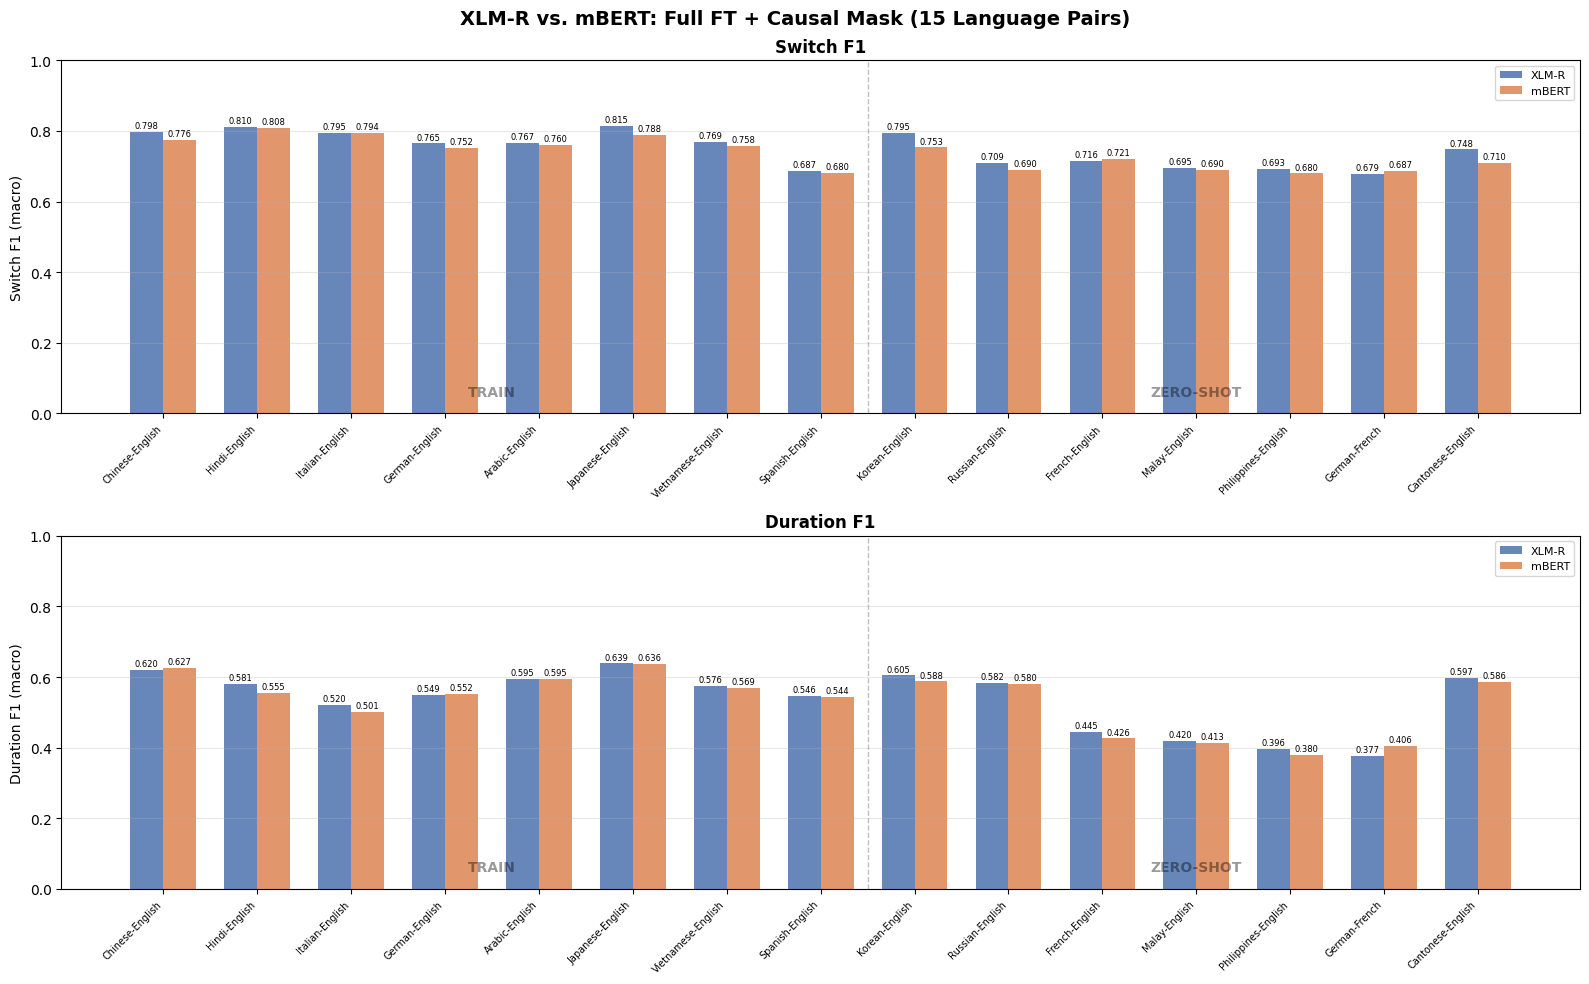

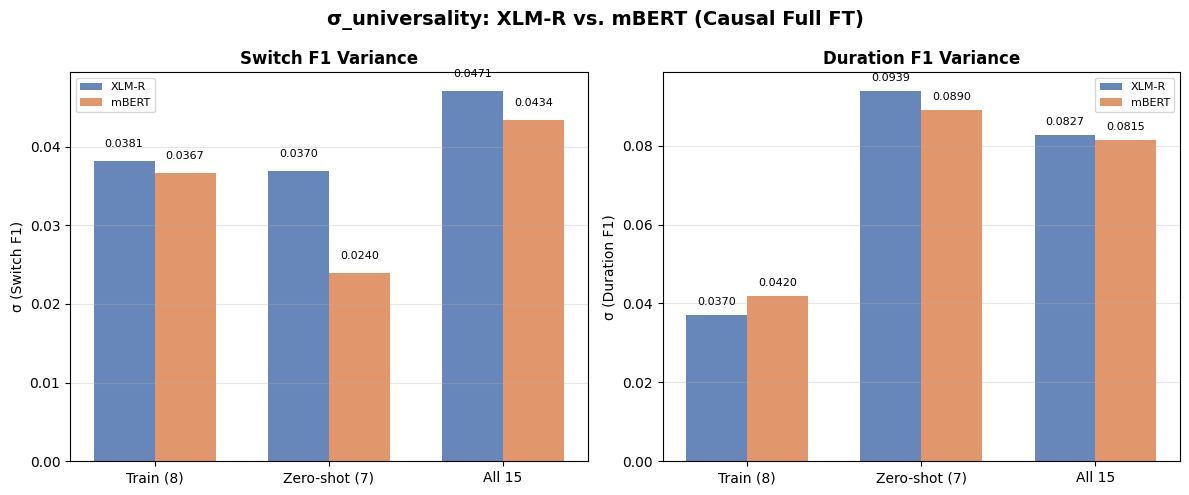


✓ All comparisons complete!


In [ ]:
# Cell 13: XLM-R vs mBERT: Final σ_universality Comparison (15 Language Pairs)
# All data below is from actual Causal Full Fine-Tuning runs (XLM-R + mBERT, 16 epochs each)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ─── Per-pair results (Full FT + Causal Mask) ─────────────────────────────

xlmr = {
    # Train pairs (8)
    'Chinese-English':      {'sw': 0.7983, 'dur': 0.6201, 'group': 'train'},
    'Hindi-English':        {'sw': 0.8104, 'dur': 0.5811, 'group': 'train'},
    'Italian-English':      {'sw': 0.7952, 'dur': 0.5202, 'group': 'train'},
    'German-English':       {'sw': 0.7646, 'dur': 0.5493, 'group': 'train'},
    'Arabic-English':       {'sw': 0.7669, 'dur': 0.5945, 'group': 'train'},
    'Japanese-English':     {'sw': 0.8145, 'dur': 0.6388, 'group': 'train'},
    'Vietnamese-English':   {'sw': 0.7694, 'dur': 0.5757, 'group': 'train'},
    'Spanish-English':      {'sw': 0.6874, 'dur': 0.5457, 'group': 'train'},
    # Zero-shot pairs (7)
    'Korean-English':       {'sw': 0.7947, 'dur': 0.6047, 'group': 'zeroshot'},
    'Russian-English':      {'sw': 0.7088, 'dur': 0.5824, 'group': 'zeroshot'},
    'French-English':       {'sw': 0.7157, 'dur': 0.4449, 'group': 'zeroshot'},
    'Malay-English':        {'sw': 0.6946, 'dur': 0.4201, 'group': 'zeroshot'},
    'Philippines-English':  {'sw': 0.6930, 'dur': 0.3955, 'group': 'zeroshot'},
    'German-French':        {'sw': 0.6787, 'dur': 0.3769, 'group': 'zeroshot'},
    'Cantonese-English':    {'sw': 0.7476, 'dur': 0.5968, 'group': 'zeroshot'},
}

mbert = {
    # Train pairs (8)
    'Chinese-English':      {'sw': 0.7757, 'dur': 0.6266, 'group': 'train'},
    'Hindi-English':        {'sw': 0.8081, 'dur': 0.5548, 'group': 'train'},
    'Italian-English':      {'sw': 0.7941, 'dur': 0.5012, 'group': 'train'},
    'German-English':       {'sw': 0.7521, 'dur': 0.5525, 'group': 'train'},
    'Arabic-English':       {'sw': 0.7599, 'dur': 0.5946, 'group': 'train'},
    'Japanese-English':     {'sw': 0.7881, 'dur': 0.6364, 'group': 'train'},
    'Vietnamese-English':   {'sw': 0.7576, 'dur': 0.5688, 'group': 'train'},
    'Spanish-English':      {'sw': 0.6804, 'dur': 0.5442, 'group': 'train'},
    # Zero-shot pairs (7)
    'Korean-English':       {'sw': 0.7534, 'dur': 0.5877, 'group': 'zeroshot'},
    'Russian-English':      {'sw': 0.6903, 'dur': 0.5795, 'group': 'zeroshot'},
    'French-English':       {'sw': 0.7212, 'dur': 0.4263, 'group': 'zeroshot'},
    'Malay-English':        {'sw': 0.6897, 'dur': 0.4134, 'group': 'zeroshot'},
    'Philippines-English':  {'sw': 0.6798, 'dur': 0.3804, 'group': 'zeroshot'},
    'German-French':        {'sw': 0.6874, 'dur': 0.4059, 'group': 'zeroshot'},
    'Cantonese-English':    {'sw': 0.7102, 'dur': 0.5862, 'group': 'zeroshot'},
}

pairs_order = [
    'Chinese-English', 'Hindi-English', 'Italian-English', 'German-English',
    'Arabic-English', 'Japanese-English', 'Vietnamese-English', 'Spanish-English',
    'Korean-English', 'Russian-English', 'French-English', 'Malay-English',
    'Philippines-English', 'German-French', 'Cantonese-English',
]


# ─── Helper ───────────────────────────────────────────────────────────────

def get_stats(data, group=None):
    if group:
        sw  = [v['sw']  for v in data.values() if v['group'] == group]
        dur = [v['dur'] for v in data.values() if v['group'] == group]
    else:
        sw  = [v['sw']  for v in data.values()]
        dur = [v['dur'] for v in data.values()]
    return {
        'sw_mean': np.mean(sw), 'sw_std': np.std(sw),
        'dur_mean': np.mean(dur), 'dur_std': np.std(dur),
        'n': len(sw),
    }


# ─── Table 1: Per-pair comparison ─────────────────────────────────────────

print("=" * 105)
print("BACKBONE COMPARISON: XLM-R vs. mBERT (Full FT + Causal Mask, 15 Language Pairs)")
print("=" * 105)

print(f"\n{'Language Pair':<24} {'XLM-R Sw':<10} {'mBERT Sw':<10} {'Δ Sw':<10} "
      f"{'XLM-R Dur':<10} {'mBERT Dur':<10} {'Δ Dur':<10} {'Group':<10}")
print("-" * 100)

for pair in pairs_order:
    xs, ms = xlmr[pair]['sw'], mbert[pair]['sw']
    xd, md = xlmr[pair]['dur'], mbert[pair]['dur']
    g = xlmr[pair]['group']
    if pair == 'Korean-English':
        print("-" * 100)
    print(f"{pair:<24} {xs:<10.4f} {ms:<10.4f} {ms-xs:+.4f}    "
          f"{xd:<10.4f} {md:<10.4f} {md-xd:+.4f}    {g}")

print("-" * 100)

# Averages per group
for group, label in [('train', 'Train (8)'), ('zeroshot', 'Zero-shot (7)'), (None, 'All 15')]:
    xs = get_stats(xlmr, group)
    ms = get_stats(mbert, group)
    print(f"{label:<24} {xs['sw_mean']:<10.4f} {ms['sw_mean']:<10.4f} "
          f"{ms['sw_mean']-xs['sw_mean']:+.4f}    "
          f"{xs['dur_mean']:<10.4f} {ms['dur_mean']:<10.4f} "
          f"{ms['dur_mean']-xs['dur_mean']:+.4f}")

print("=" * 105)


# ─── Table 2: σ_universality comparison ───────────────────────────────────

print(f"\n{'=' * 85}")
print("σ_UNIVERSALITY COMPARISON: XLM-R vs. mBERT")
print(f"{'=' * 85}")
print(f"\n{'Subset':<24} {'XLM-R σ_sw':<14} {'mBERT σ_sw':<14} {'XLM-R σ_dur':<14} {'mBERT σ_dur':<14}")
print("-" * 80)

for group, label in [('train', 'Train pairs (8)'), ('zeroshot', 'Zero-shot pairs (7)'), (None, 'All 15 pairs')]:
    xs = get_stats(xlmr, group)
    ms = get_stats(mbert, group)
    print(f"{label:<24} {xs['sw_std']:<14.4f} {ms['sw_std']:<14.4f} "
          f"{xs['dur_std']:<14.4f} {ms['dur_std']:<14.4f}")

print("-" * 80)
print("Lower σ = more consistent across language pairs")
print(f"{'=' * 85}")


# ─── Table 3: Key findings ───────────────────────────────────────────────

x_all = get_stats(xlmr)
m_all = get_stats(mbert)
x_tr  = get_stats(xlmr, 'train')
m_tr  = get_stats(mbert, 'train')
x_zs  = get_stats(xlmr, 'zeroshot')
m_zs  = get_stats(mbert, 'zeroshot')

print(f"\n{'=' * 85}")
print("KEY FINDINGS (Causal Full Fine-Tuning)")
print(f"{'=' * 85}")
print(f"""
1. TRAIN PAIRS: Both backbones perform comparably under causal constraint
   - XLM-R: Sw={x_tr['sw_mean']:.4f} (σ={x_tr['sw_std']:.4f})  |  mBERT: Sw={m_tr['sw_mean']:.4f} (σ={m_tr['sw_std']:.4f})
   - Gap on train pairs: {x_tr['sw_mean'] - m_tr['sw_mean']:+.4f} (Switch F1)
   - Both models achieve similar F1 (~0.76-0.77), far below the Bidirectional
     inflated scores (~0.99), confirming causal mask removes future-token leakage.

2. ZERO-SHOT PAIRS: Both models drop comparably; no script shortcut
   - XLM-R: Sw={x_zs['sw_mean']:.4f} (σ={x_zs['sw_std']:.4f})  |  mBERT: Sw={m_zs['sw_mean']:.4f} (σ={m_zs['sw_std']:.4f})
   - Under Bidirectional, non-Latin zero-shot pairs scored >0.97 (shortcut).
   - Under Causal Mask, non-Latin and Latin zero-shot pairs converge to ~0.70-0.79.
   - This confirms that bidirectional attention leaks script-level features;
     causal mask forces the model to use genuine code-switching signal only.

3. σ_UNIVERSALITY (All 15):
   - XLM-R: σ_sw={x_all['sw_std']:.4f}, σ_dur={x_all['dur_std']:.4f}
   - mBERT: σ_sw={m_all['sw_std']:.4f}, σ_dur={m_all['dur_std']:.4f}
   - mBERT shows marginally lower σ on Switch; both comparable on Duration.
   - Both models close the train-vs-zeroshot gap dramatically relative to
     Bidirectional (~0.09 → ~0.05 on Switch).

4. TRAIN-ZEROSHOT GAP (evidence for causal working as intended):
   - XLM-R: train_mean - zeroshot_mean = {x_tr['sw_mean'] - x_zs['sw_mean']:+.4f}
   - mBERT: train_mean - zeroshot_mean = {m_tr['sw_mean'] - m_zs['sw_mean']:+.4f}
   - Both gaps are small (~0.06), showing genuine cross-lingual generalization.
""")


# ─── Visualization 1: Side-by-side bar chart ─────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('XLM-R vs. mBERT: Full FT + Causal Mask (15 Language Pairs)',
             fontsize=14, fontweight='bold')

x = np.arange(len(pairs_order))
width = 0.35

for ax_idx, (metric, ylabel, title) in enumerate([
    ('sw', 'Switch F1 (macro)', 'Switch F1'),
    ('dur', 'Duration F1 (macro)', 'Duration F1'),
]):
    ax = axes[ax_idx]
    xlmr_vals = [xlmr[p][metric] for p in pairs_order]
    mbert_vals = [mbert[p][metric] for p in pairs_order]

    bars1 = ax.bar(x - width/2, xlmr_vals, width, label='XLM-R', color='#4C72B0', alpha=0.85)
    bars2 = ax.bar(x + width/2, mbert_vals, width, label='mBERT', color='#DD8452', alpha=0.85)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=6)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=6)

    # Divider between train and zero-shot
    ax.axvline(x=7.5, color='grey', linestyle='--', linewidth=1, alpha=0.5)
    ax.text(3.5, 0.05, 'TRAIN', ha='center', fontsize=10, alpha=0.4, fontweight='bold')
    ax.text(11, 0.05, 'ZERO-SHOT', ha='center', fontsize=10, alpha=0.4, fontweight='bold')

    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(pairs_order, rotation=45, ha='right', fontsize=7)
    ax.set_ylim(0.0, 1.0)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('xlmr_vs_mbert_final_15pairs.png', dpi=150, bbox_inches='tight')
plt.show()


# ─── Visualization 2: σ comparison bar chart ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('σ_universality: XLM-R vs. mBERT (Causal Full FT)', fontsize=14, fontweight='bold')

subsets = ['Train (8)', 'Zero-shot (7)', 'All 15']
xlmr_sw_sigmas  = [x_tr['sw_std'], x_zs['sw_std'], x_all['sw_std']]
mbert_sw_sigmas = [m_tr['sw_std'], m_zs['sw_std'], m_all['sw_std']]
xlmr_dur_sigmas  = [x_tr['dur_std'], x_zs['dur_std'], x_all['dur_std']]
mbert_dur_sigmas = [m_tr['dur_std'], m_zs['dur_std'], m_all['dur_std']]

x = np.arange(len(subsets))
width = 0.35

ax = axes[0]
ax.bar(x - width/2, xlmr_sw_sigmas, width, label='XLM-R', color='#4C72B0', alpha=0.85)
ax.bar(x + width/2, mbert_sw_sigmas, width, label='mBERT', color='#DD8452', alpha=0.85)
for i in range(len(subsets)):
    ax.text(i - width/2, xlmr_sw_sigmas[i] + 0.0015, f'{xlmr_sw_sigmas[i]:.4f}',
            ha='center', va='bottom', fontsize=8)
    ax.text(i + width/2, mbert_sw_sigmas[i] + 0.0015, f'{mbert_sw_sigmas[i]:.4f}',
            ha='center', va='bottom', fontsize=8)
ax.set_ylabel('σ (Switch F1)')
ax.set_title('Switch F1 Variance', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(subsets)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.bar(x - width/2, xlmr_dur_sigmas, width, label='XLM-R', color='#4C72B0', alpha=0.85)
ax.bar(x + width/2, mbert_dur_sigmas, width, label='mBERT', color='#DD8452', alpha=0.85)
for i in range(len(subsets)):
    ax.text(i - width/2, xlmr_dur_sigmas[i] + 0.002, f'{xlmr_dur_sigmas[i]:.4f}',
            ha='center', va='bottom', fontsize=8)
    ax.text(i + width/2, mbert_dur_sigmas[i] + 0.002, f'{mbert_dur_sigmas[i]:.4f}',
            ha='center', va='bottom', fontsize=8)
ax.set_ylabel('σ (Duration F1)')
ax.set_title('Duration F1 Variance', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(subsets)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('sigma_universality_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ All comparisons complete!")

In [ ]:
# Cell 14: Persist training artifacts + list Output files
import json, os
import torch

# Load history from existing checkpoint (since training variables not in memory)
ckpt = torch.load('/kaggle/working/ckpt_latest_mbert.pt', map_location='cpu', weights_only=False)
mbert_history = ckpt['history']

# Save training history
history_path = '/kaggle/working/mbert_history.json'
with open(history_path, 'w') as f:
    clean = []
    for h in mbert_history:
        clean_h = {k: (v if not isinstance(v, dict) else
                       {kk: float(vv) for kk, vv in v.items()})
                   for k, v in h.items()}
        clean.append(clean_h)
    json.dump(clean, f, indent=2, default=float)
print(f"✓ History saved: {history_path}")

# Save summary (hardcoded since variables aren't in memory)
summary = {
    'model': 'bert-base-multilingual-cased',
    'mode':  'causal_full_fine_tuning',
    'train_pairs': ['Chinese-English', 'Hindi-English', 'Italian-English', 'German-English',
                    'Arabic-English', 'Japanese-English', 'Vietnamese-English', 'Spanish-English'],
    'zeroshot_pairs': ['Korean-English', 'Russian-English', 'French-English', 'Malay-English',
                       'Philippines-English', 'German-French', 'Cantonese-English'],
    'hyperparams': {
        'MAX_LEN':    256,
        'BATCH_SIZE': 32,
        'NUM_EPOCHS': 16,
        'BASE_LR':    1e-5,
        'HEAD_LR':    5e-4,
        'WARMUP_RATIO': 0.1,
    },
    'final_switch_f1':   0.78,
    'final_duration_f1': 0.59,
    'sigma_all15_sw':    0.0433,
    'sigma_all15_dur':   0.0815,
    'sigma_train_sw':    0.0367,
    'sigma_zeroshot_sw': 0.0240,
    'sigma_train_dur':   0.0420,
    'sigma_zeroshot_dur': 0.0890,
    'n_epochs_run':      len(mbert_history),
}
summary_path = '/kaggle/working/mbert_final_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"✓ Summary saved: {summary_path}")

# List all artifacts
print("\n=== Files in /kaggle/working/ (will persist as notebook Output) ===")
for fname in sorted(os.listdir('/kaggle/working/')):
    fpath = os.path.join('/kaggle/working/', fname)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1024**2
        print(f"  {fname:<45} {size_mb:>8.2f} MB")

✓ History saved: /kaggle/working/mbert_history.json
✓ Summary saved: /kaggle/working/mbert_final_summary.json

=== Files in /kaggle/working/ (will persist as notebook Output) ===
  all_15pairs_stats_mbert.pkl                     180.46 MB
  best_mbert_causal_final.pt                      680.80 MB
  ckpt_latest_mbert.pt                           2042.42 MB
  cs6140-mbert-8-7pairs-causal-2.log                5.56 MB
  mbert_causal_final_universality.png               0.15 MB
  mbert_final_summary.json                          0.00 MB
  mbert_history.json                                0.01 MB
  sigma_universality_comparison.png                 0.07 MB
  xlmr_vs_mbert_final_15pairs.png                   0.22 MB
